<a href="https://colab.research.google.com/github/samriddhisingh05/1BM23CS295_Samriddhi_Singh_ML_Lab/blob/main/1BM23CS295_Lab_7_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
data = pd.read_csv("iris.csv")

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
svm_linear = SVC(kernel='linear', probability=True)
svm_rbf = SVC(kernel='rbf', probability=True)

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

print("Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Linear Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))

print("RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("RBF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Linear Accuracy: 1.0
Linear Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
RBF Accuracy: 1.0
RBF Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

y_score_linear = svm_linear.predict_proba(X_test)
y_score_rbf = svm_rbf.predict_proba(X_test)

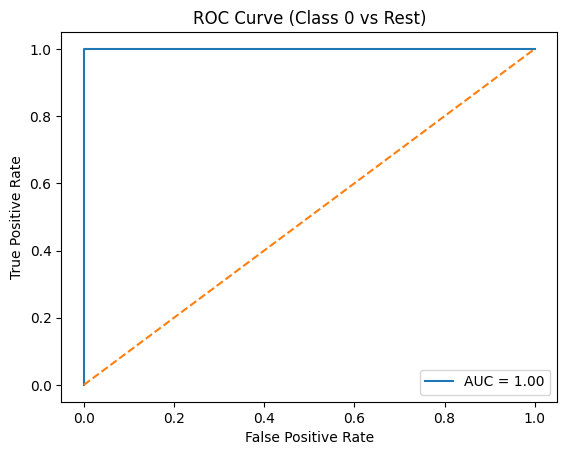

In [ ]:
plt.figure()

fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score_rbf[:, 0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 0 vs Rest)")
plt.legend()

plt.show()

In [ ]:
data = pd.read_csv("letter-recognition.csv")

X = data.iloc[:, 1:]
y = data.iloc[:, 0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0   0 

In [ ]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = svm.predict_proba(X_test)

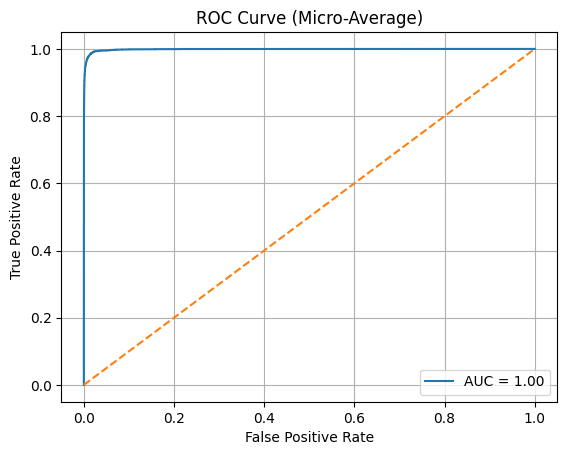

In [ ]:
plt.figure()

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend()
plt.grid()

plt.show()